In [134]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import re

# Constants
WIDE_FIGSIZE = 6
HEIGHT_FIGSIZE = 2
FONTSIZE = 12
BAR_WIDTH = 0.2
group_spacing = 0.4
code_palette = sns.color_palette("pastel", n_colors=8)
code_hatches = ["/", "\\", "//", "++", "xx", "**"]

def plot_logical_error_rate(csv_path, decoding_time=True, cycles=100):
    """
    Styled two-subplot figure with:
    - Points on top of bars with black edge, connected by lines
    - Background color for readout time plot (green ≤1.0, red >1.0)
    - Gray dashed grid
    """

    df = pd.read_csv(csv_path)
    df = df[df['cycles'] == cycles]

    # Filter by decoding_time
    if decoding_time:
        df = df[df['error_type'].str.endswith('_2', na=False)]
    else:
        df = df[~df['error_type'].str.endswith('_2', na=False)]

    # Parse error_type
    def parse_error_type(s):
        nums = re.findall(r"[-+]?\d*\.?\d+", str(s))
        if len(nums) < 2:
            return None, None
        nums = nums[-3:]
        return float(nums[0]), float(nums[1])

    df[['error_multiplier', 'time']] = df['error_type'].apply(lambda x: pd.Series(parse_error_type(x)))
    df['logical_error_rate'] = pd.to_numeric(df['logical_error_rate'])
    distances = sorted(df['distance'].unique())

    fig, axes = plt.subplots(1, 2, figsize=(WIDE_FIGSIZE * 1.3, HEIGHT_FIGSIZE * 1.8))

    # ------------------------------
    # Left plot (a): error multiplier
    # ------------------------------
    df_time_1 = df[df['time'] == 1]
    x_vals = sorted(df_time_1['error_multiplier'].dropna().unique())
    x = np.arange(len(x_vals)) * (BAR_WIDTH * len(distances) + group_spacing)


    for i, d in enumerate(distances):
        values = []
        for xm in x_vals:
            subset = df_time_1[(df_time_1['error_multiplier'] == xm) & (df_time_1['distance'] == d)]
            values.append(subset['logical_error_rate'].values[0] if not subset.empty else np.nan)
        axes[0].bar(x + i*BAR_WIDTH, values, width=BAR_WIDTH,
                    color=code_palette[i % len(code_palette)],
                    hatch=code_hatches[i % len(code_hatches)],
                    edgecolor='black', label=f"d={d}")
        # Points on top of bars with black edge
        axes[0].plot(x + i*BAR_WIDTH, values, '-o',
                     color=code_palette[i % len(code_palette)],
                     markersize=3, markeredgecolor='black')

    axes[0].margins(x=0)
    axes[0].set_yscale("log")
    axes[0].set_xticks(x + BAR_WIDTH)
    axes[0].set_xticklabels([f"{xm:.2f}x" for xm in x_vals], fontsize=FONTSIZE-2)
    axes[0].set_xlabel("Scale of MCM error", fontsize=FONTSIZE)
    axes[0].set_ylabel("Logical error rate (log)", fontsize=FONTSIZE)
    axes[0].set_title("(a) MCM error rate", fontsize=FONTSIZE, fontweight="bold")
    axes[0].legend(fontsize=FONTSIZE-2, loc="upper left",)
    axes[0].text(0.53, 1.2, "Lower is better ↓", transform=axes[0].transAxes,
                 fontsize=FONTSIZE, fontweight="bold", color="blue", va="top", ha="center")
    axes[0].set_axisbelow(True)
    axes[0].grid(color='gray')

    # ------------------------------
    # Right plot (b): time
    # ------------------------------
    df_error_1 = df[df['error_multiplier'] == 1]
    x_vals = sorted(df_error_1['time'].dropna().unique())
    x = np.arange(len(x_vals)) * (BAR_WIDTH * len(distances) + group_spacing)

    # Background coloring to the full plot
    axes[1].margins(x=0)
    axes[1].set_yscale("log")
    axes[1].axvspan(-0.5, np.searchsorted(x_vals, 1.0) - 0.5, facecolor='green', alpha=0.1)
    axes[1].axvspan(np.searchsorted(x_vals, 1.0) - 0.5, np.searchsorted(x_vals, 1.0) + 3, facecolor='red', alpha=0.1)

    for i, d in enumerate(distances):
        values = []
        for t in x_vals:
            subset = df_error_1[(df_error_1['time'] == t) & (df_error_1['distance'] == d)]
            values.append(subset['logical_error_rate'].values[0] if not subset.empty else np.nan)
        axes[1].bar(x + i*BAR_WIDTH, values, width=BAR_WIDTH,
                    color=code_palette[i % len(code_palette)],
                    hatch=code_hatches[i % len(code_hatches)],
                    edgecolor='black')
        axes[1].plot(x + i*BAR_WIDTH, values, '-o',
                     color=code_palette[i % len(code_palette)],
                     markersize=3, markeredgecolor='black')

    axes[1].set_xticks(x + BAR_WIDTH)
    axes[1].set_xticklabels([f"{t:.2f}" for t in x_vals], fontsize=FONTSIZE-2)
    axes[1].set_xlabel("Readout time (µs)", fontsize=FONTSIZE)
    axes[1].set_ylabel("Logical error rate (log)", fontsize=FONTSIZE)
    axes[1].set_title("(b) MCM duration", fontsize=FONTSIZE, fontweight="bold")
    axes[1].text(0.53, 1.2, "Lower is better ↓", transform=axes[1].transAxes,
                 fontsize=FONTSIZE, fontweight="bold", color="blue", va="top", ha="center")
    axes[1].set_axisbelow(True)
    axes[1].grid(color='gray')

    axes[0].tick_params(axis='both', labelsize=FONTSIZE-2)
    axes[1].tick_params(axis='both', labelsize=FONTSIZE-2)

    plt.tight_layout()
    plt.show()

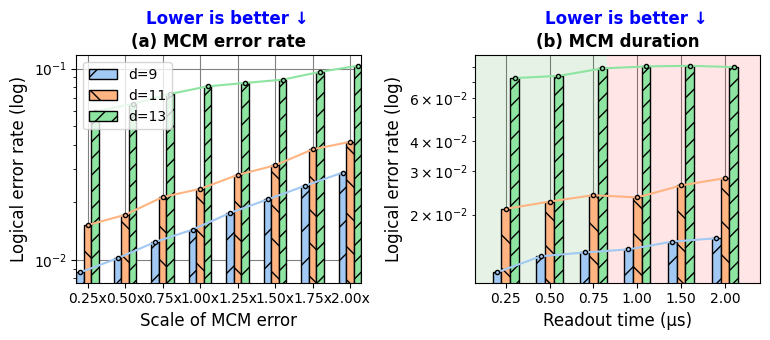

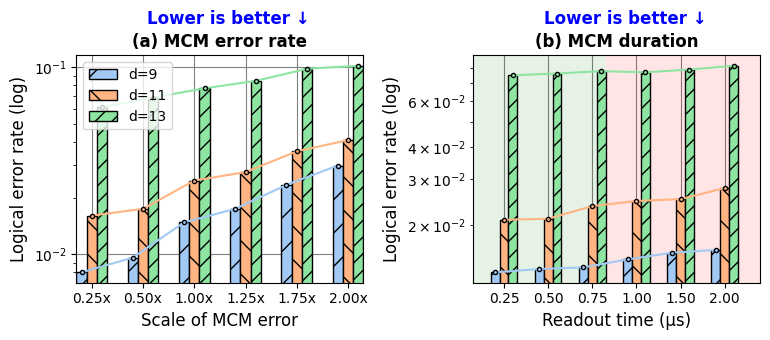

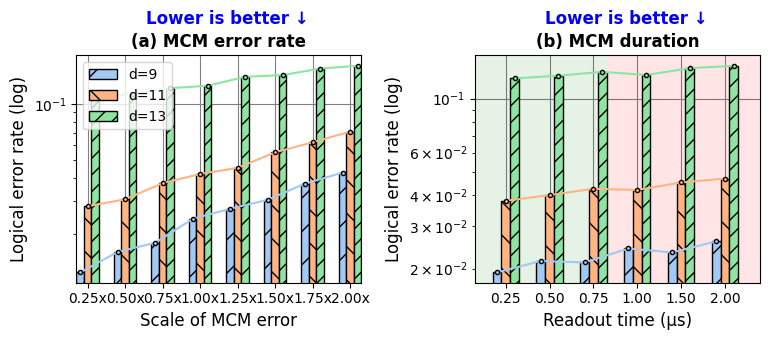

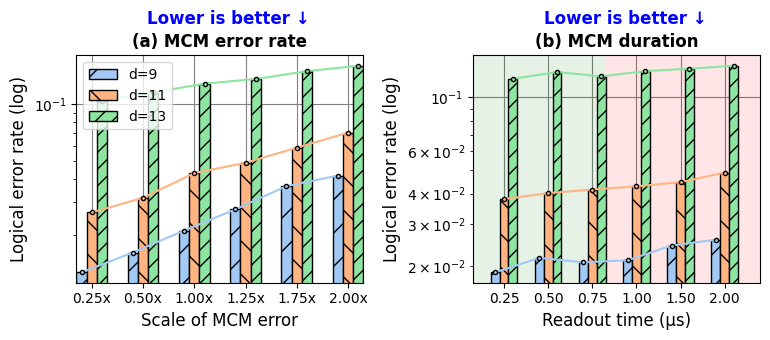

In [56]:
plot_logical_error_rate("../experiment_results/MCM/results.csv", False)
plot_logical_error_rate("../experiment_results/MCM/results.csv", True)
plot_logical_error_rate("../experiment_results/MCM/results.csv", False, 200)
plot_logical_error_rate("../experiment_results/MCM/results.csv", True, 200)

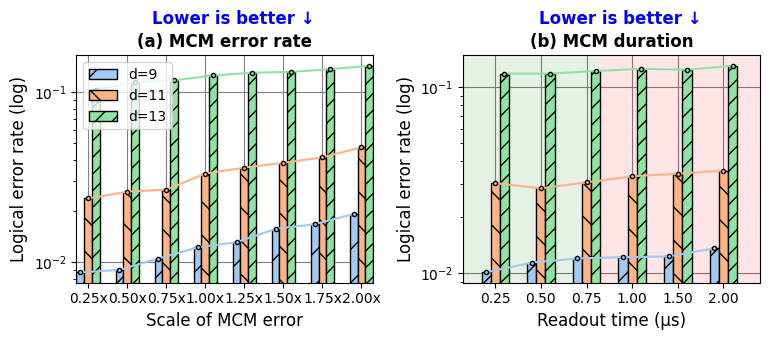

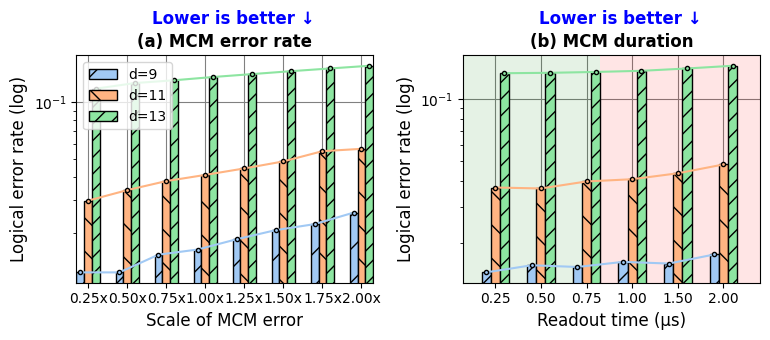

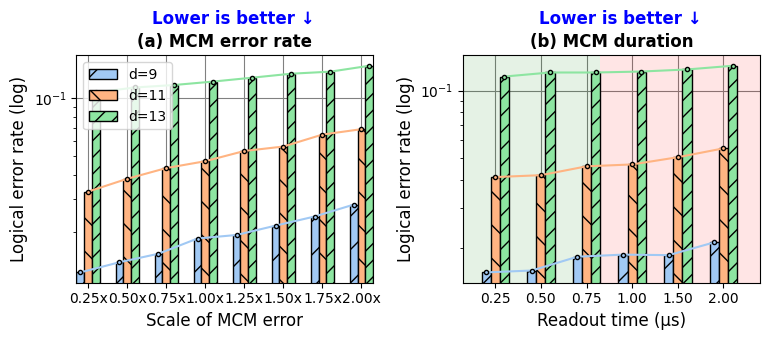

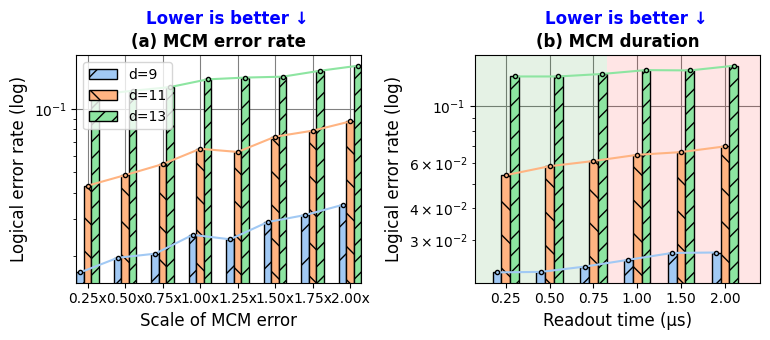

In [63]:
plot_logical_error_rate("../experiment_results/MCM_flamingo/results.csv", False)
plot_logical_error_rate("../experiment_results/MCM_flamingo/results.csv", True)
plot_logical_error_rate("../experiment_results/MCM_flamingo/results.csv", False, 200)
plot_logical_error_rate("../experiment_results/MCM_flamingo/results.csv", True, 200)

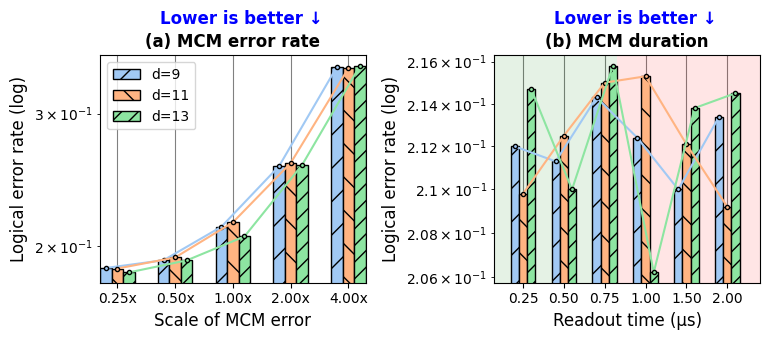

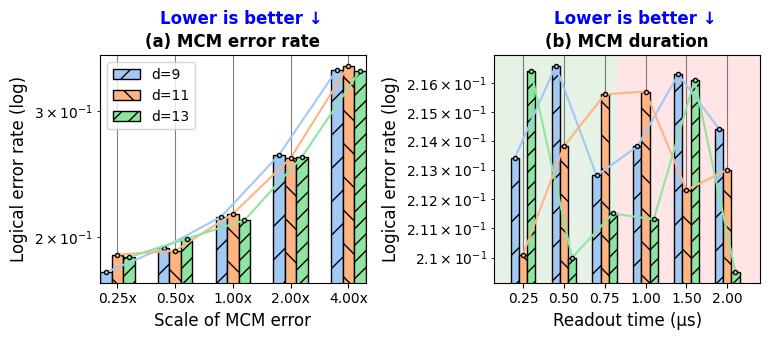

In [58]:
plot_logical_error_rate("../experiment_results/MCM_flamingo_ft_s/results.csv", False, 13)
plot_logical_error_rate("../experiment_results/MCM_flamingo_ft_s/results.csv", True, 13)

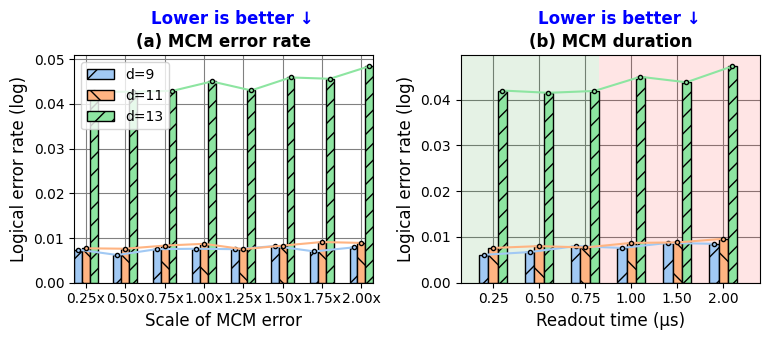

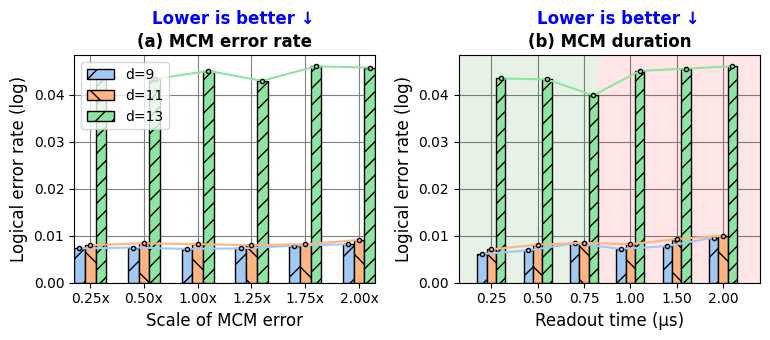

In [41]:
plot_logical_error_rate("../experiment_results/MCM_futuristic/results.csv", False)
plot_logical_error_rate("../experiment_results/MCM_futuristic/results.csv", True)

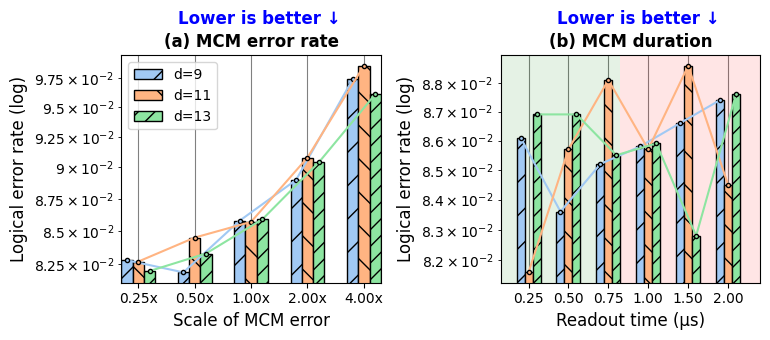

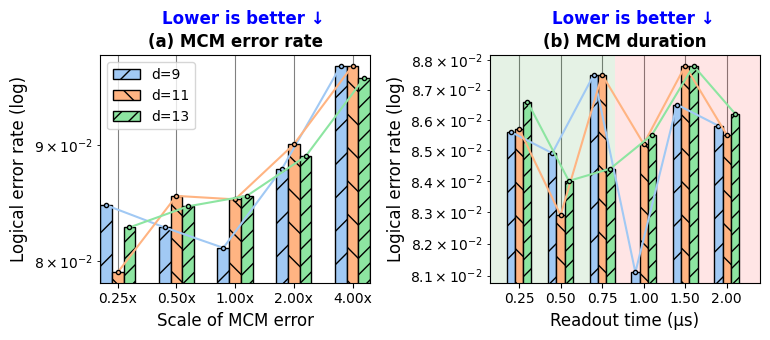

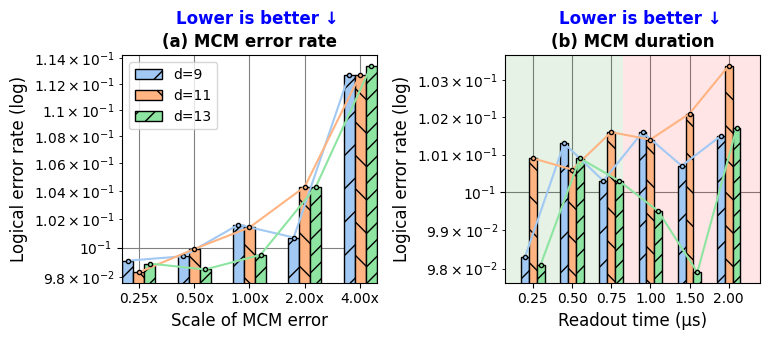

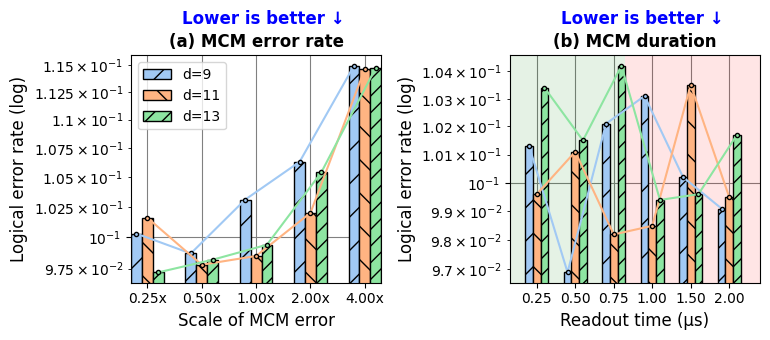

In [61]:
plot_logical_error_rate("../experiment_results/MCM_futuristic_ft_s/results.csv", False, 1)
plot_logical_error_rate("../experiment_results/MCM_futuristic_ft_s/results.csv", True, 1)
plot_logical_error_rate("../experiment_results/MCM_futuristic_ft_s/results.csv", False, 3)
plot_logical_error_rate("../experiment_results/MCM_futuristic_ft_s/results.csv", True, 3)

In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import re

def plot_time_only(csv_path):
    """
    Plots logical error rate vs time (µs).
    Shows grouped bars for distances (7, 9, 11).
    Assumes error_type format: mcm_<multiplier>_<time>
    """

    df = pd.read_csv(csv_path)

    # Extract multiplier and time from error_type
    def parse_error_type(s):
        nums = re.findall(r"[-+]?\d*\.?\d+", str(s))
        if len(nums) < 2:
            return None, None
        multiplier = float(nums[0])
        time = float(nums[1])
        return multiplier, time

    df[["error_multiplier", "time"]] = df["error_type"].apply(
        lambda x: pd.Series(parse_error_type(x))
    )

    df["logical_error_rate"] = pd.to_numeric(df["logical_error_rate"])

    distances = sorted(df["distance"].unique())
    times = sorted(df["time"].unique())

    x = np.arange(len(times))
    bar_width = 0.25

    plt.figure(figsize=(8, 6))

    for i, d in enumerate(distances):
        values = []
        for t in times:
            subset = df[(df["distance"] == d) & (df["time"] == t)]
            values.append(
                subset["logical_error_rate"].values[0]
                if not subset.empty else np.nan
            )

        plt.bar(x + i * bar_width, values, width=bar_width, label=f"d={d}")

    plt.xticks(x + bar_width, times)
    plt.yscale("log")
    plt.xlabel("Time (µs)")
    plt.ylabel("Logical Error Rate")
    plt.title("Logical Error Rate vs Time")
    plt.legend()

    plt.tight_layout()
    plt.show()

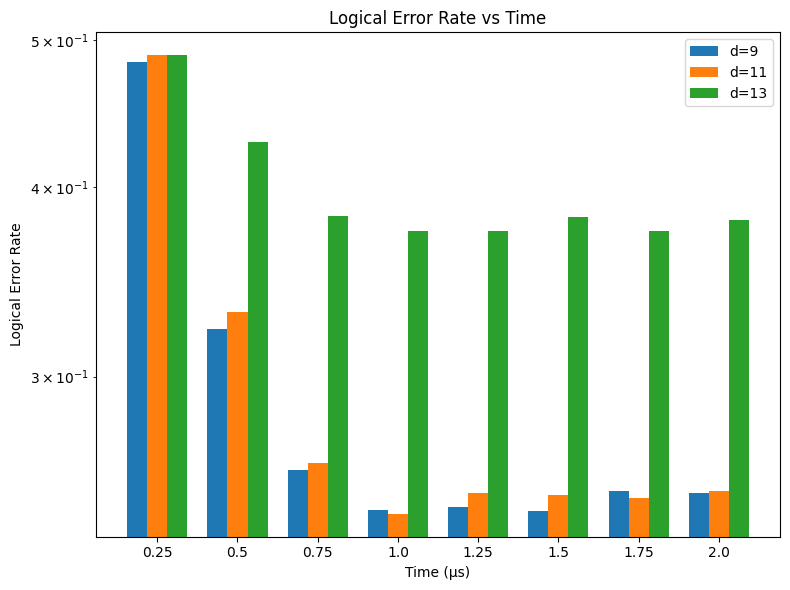

In [44]:
plot_time_only("../experiment_results/MCM_tradeoff/results.csv")

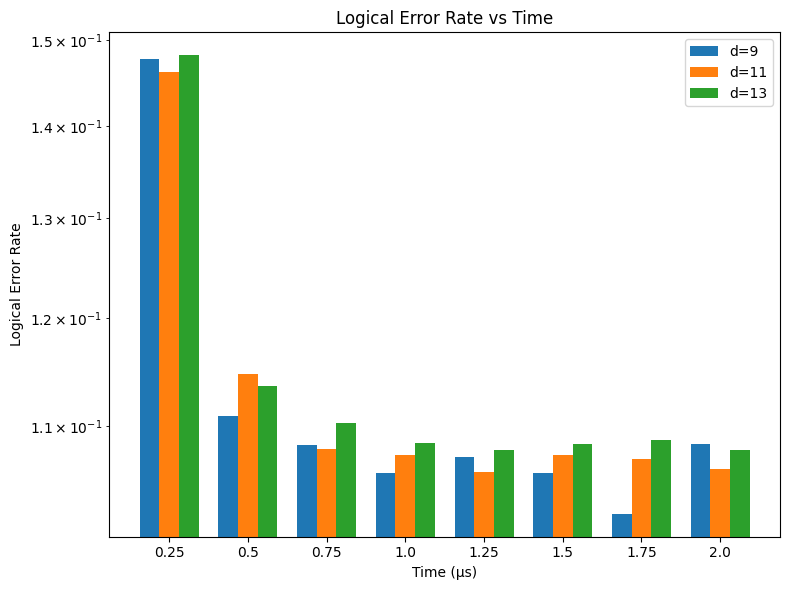

In [62]:
plot_time_only("../experiment_results/MCM_tradeoff_futuristic_ft_s/results.csv")

In [49]:
plot_time_only("../experiment_results/MCM_tradeoff_futuristic/results.csv")

FileNotFoundError: [Errno 2] No such file or directory: '../experiment_results/MCM_tradeoff_futuristic_s/results.csv'

In [47]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import re

# Constants
WIDE_FIGSIZE = 6
HEIGHT_FIGSIZE = 2
FONTSIZE = 12
code_palette = sns.color_palette("pastel", n_colors=8)
markers = ["o", "s", "D", "^", "v", "P", "X", "*"]

def plot_logical_error_vs_cycles(csv_path, dist=9):
    """
    Linear plot:
    - X-axis: cycles
    - Y-axis: logical error rate
    - Only distance = 9
    - One line per error_type
    """

    df = pd.read_csv(csv_path)
    df = df[df["distance"] == dist]   # 🔹 Filter to distance 9
    df["logical_error_rate"] = pd.to_numeric(df["logical_error_rate"])

    fig, ax = plt.subplots(figsize=(WIDE_FIGSIZE*2, HEIGHT_FIGSIZE*3))

    unique_error_types = sorted(df["error_type"].unique())

    for i, et in enumerate(unique_error_types):
        subset = df[df["error_type"] == et].sort_values("cycles")

        ax.plot(
            subset["cycles"],
            subset["logical_error_rate"],
            marker=markers[i % len(markers)],
            color=code_palette[i % len(code_palette)],
            linewidth=1.8,
            markersize=6,
            label=et
        )

    ax.set_xlabel("Cycles", fontsize=FONTSIZE)
    ax.set_ylabel("Logical Error Rate", fontsize=FONTSIZE)

    ax.set_title("(a) Logical Error Rate vs Cycles (d=9)",
                 fontsize=FONTSIZE,
                 fontweight="bold",
                 pad=15)

    ax.legend(fontsize=FONTSIZE)

    ax.text(
        1.0, 1.16, "Lower is better ↓",
        transform=ax.transAxes,
        fontsize=FONTSIZE,
        fontweight="bold",
        color="blue",
        va="top",
        ha="right"
    )

    plt.show()

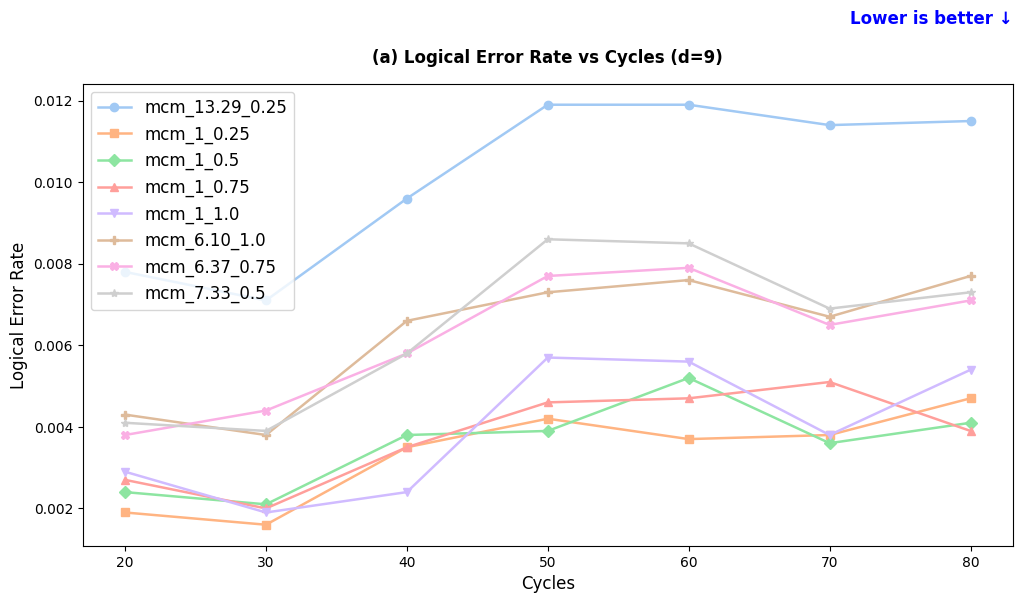

In [48]:
plot_logical_error_vs_cycles("../experiment_results/MCM_cycles/results.csv", 9)

In [132]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Constants (UNCHANGED)
WIDE_FIGSIZE = 6
HEIGHT_FIGSIZE = 2
FONTSIZE = 12
BAR_WIDTH = 0.2
group_spacing = 0.4
code_palette = sns.color_palette("pastel", n_colors=8)
code_hatches = ["/", "\\", "//", "++", "xx", "**"]

def plot_logical_error_rate(measure_csv, duration_csv, combined_csv):

    df_measure = pd.read_csv(measure_csv)
    df_duration = pd.read_csv(duration_csv)
    df_combined = pd.read_csv(combined_csv)

    df_measure['logical_error_rate'] = pd.to_numeric(df_measure['logical_error_rate'])
    df_duration['logical_error_rate'] = pd.to_numeric(df_duration['logical_error_rate'])
    df_combined['logical_error_rate'] = pd.to_numeric(df_combined['logical_error_rate'])

    distances = sorted(df_measure['distance'].unique())

    fig, axes = plt.subplots(
        1, 3,
        figsize=(WIDE_FIGSIZE * 2.8, HEIGHT_FIGSIZE * 1.0)
    )

    LOWER_TEXT_Y = 1.29  # SAME HEIGHT FOR ALL PANELS

    # ==================================================
    # (a) Measurement error plot
    # ==================================================
    x_vals = sorted(df_measure['measure_error'].unique())
    x = np.arange(len(x_vals)) * (BAR_WIDTH * len(distances) + group_spacing)

    for i, d in enumerate(distances):
        values = []
        for xm in x_vals:
            subset = df_measure[
                (df_measure['measure_error'] == xm) &
                (df_measure['distance'] == d)
            ]
            values.append(subset['logical_error_rate'].values[0] if not subset.empty else np.nan)

        axes[0].bar(
            x + i * BAR_WIDTH,
            values,
            width=BAR_WIDTH,
            color=code_palette[i % len(code_palette)],
            hatch=code_hatches[i % len(code_hatches)],
            edgecolor='black',
            label=f"d={d}"
        )

        axes[0].plot(
            x + i * BAR_WIDTH,
            values,
            '-o',
            color=code_palette[i % len(code_palette)],
            markersize=3,
            markeredgecolor='black'
        )

    axes[0].margins(x=0)
    axes[0].set_yscale("log")
    axes[0].set_xticks(x + BAR_WIDTH)
    axes[0].set_xticklabels(
        [f"{xm:.3f}" if xm < 0.01 else f"{xm:.2f}" for xm in x_vals],
        fontsize=FONTSIZE - 2
    )
    axes[0].set_xlabel("Measurement error rate", fontsize=FONTSIZE)
    axes[0].set_ylabel("Log. err. rate (log)", fontsize=FONTSIZE)
    axes[0].set_title("(a) Measurement error", fontsize=FONTSIZE, fontweight="bold")

    axes[0].text(
        0.53, LOWER_TEXT_Y, "Lower is better ↓",
        transform=axes[0].transAxes,
        fontsize=FONTSIZE, fontweight="bold",
        color="blue", va="top", ha="center"
    )

    axes[0].set_axisbelow(True)
    axes[0].grid(color='gray')
    axes[0].legend(fontsize=FONTSIZE - 2)

    # ==================================================
    # (b) Duration plot
    # ==================================================
    x_vals = sorted(df_duration['mcm_latency_ns'].unique())
    x = np.arange(len(x_vals)) * (BAR_WIDTH * len(distances) + group_spacing)

    for i, d in enumerate(distances):
        values = []
        for t in x_vals:
            subset = df_duration[
                (df_duration['mcm_latency_ns'] == t) &
                (df_duration['distance'] == d)
            ]
            values.append(subset['logical_error_rate'].values[0] if not subset.empty else np.nan)

        axes[1].bar(
            x + i * BAR_WIDTH,
            values,
            width=BAR_WIDTH,
            color=code_palette[i % len(code_palette)],
            hatch=code_hatches[i % len(code_hatches)],
            edgecolor='black',
            label=f"d={d}"   # <-- FIX: label needed for legend
        )

        axes[1].plot(
            x + i * BAR_WIDTH,
            values,
            '-o',
            color=code_palette[i % len(code_palette)],
            markersize=3,
            markeredgecolor='black'
        )

    axes[1].margins(x=0)
    axes[1].set_yscale("log")
    axes[1].set_xticks(x + BAR_WIDTH)
    axes[1].set_xticklabels(
        [f"{int(t)}" for t in x_vals],
        fontsize=FONTSIZE - 2
    )
    axes[1].set_xlabel("MCM latency (ns)", fontsize=FONTSIZE)
    axes[1].set_ylabel("Log. err. rate (log)", fontsize=FONTSIZE)
    axes[1].set_title("(b) MCM duration", fontsize=FONTSIZE, fontweight="bold")

    axes[1].text(
        0.53, LOWER_TEXT_Y, "Lower is better ↓",
        transform=axes[1].transAxes,
        fontsize=FONTSIZE, fontweight="bold",
        color="blue", va="top", ha="center"
    )

    axes[1].set_axisbelow(True)
    axes[1].grid(color='gray')
    axes[1].legend(fontsize=FONTSIZE - 2)  # now works

    # ==================================================
    # (c) Joint sweep (legend outside)
    # ==================================================
    x_vals = sorted(df_combined['measure_error'].unique())
    latency_vals = sorted(df_combined['measure_latency_ns'].unique())

    for i, latency in enumerate(latency_vals):
        values = []
        for xm in x_vals:
            subset = df_combined[
                (df_combined['measure_error'] == xm) &
                (df_combined['measure_latency_ns'] == latency)
            ]
            values.append(subset['logical_error_rate'].values[0] if not subset.empty else np.nan)

        axes[2].plot(
            x_vals,
            values,
            '-o',
            color=code_palette[i % len(code_palette)],
            markeredgecolor='black',
            markersize=4,
            label=f"{int(latency)} ns"
        )

    axes[2].set_yscale("log")
    axes[2].set_xlabel("Measurement error rate", fontsize=FONTSIZE)
    axes[2].set_ylabel("Log. err. rate (log)", fontsize=FONTSIZE)
    axes[2].set_title("(c) MCM error and duration combination", fontsize=FONTSIZE, fontweight="bold")

    axes[2].text(
        0.53, LOWER_TEXT_Y, "Lower is better ↓",
        transform=axes[2].transAxes,
        fontsize=FONTSIZE, fontweight="bold",
        color="blue", va="top", ha="center"
    )

    axes[2].grid(color='gray')

    # LEGEND OUTSIDE RIGHT
    axes[2].legend(
        fontsize=FONTSIZE - 2,
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        borderaxespad=0
    )

    axes[0].tick_params(axis='both', labelsize=FONTSIZE - 2)
    axes[1].tick_params(axis='both', labelsize=FONTSIZE - 2)
    axes[2].tick_params(axis='both', labelsize=FONTSIZE - 2)

    fig.patch.set_edgecolor("blue")
    fig.patch.set_linewidth(3)

    plt.subplots_adjust(left=0.07, right=0.92, bottom=0.15, top=0.75)
    plt.savefig("../data/mcm_motivation.pdf", format="pdf")
    plt.close(fig)

In [217]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Constants (UNCHANGED)
WIDE_FIGSIZE = 6
HEIGHT_FIGSIZE = 2
FONTSIZE = 12
BAR_WIDTH = 0.2
group_spacing = 0.4
code_palette = sns.color_palette("pastel", n_colors=8)
code_hatches = ["/", "\\", "//", "++", "xx", "**"]

def plot_logical_error_rate_two_panel(measure_csv, duration_csv):

    df_measure = pd.read_csv(measure_csv)
    df_duration = pd.read_csv(duration_csv)

    df_measure['logical_error_rate'] = pd.to_numeric(df_measure['logical_error_rate'])
    df_duration['logical_error_rate'] = pd.to_numeric(df_duration['logical_error_rate'])

    distances = sorted(df_measure['distance'].unique())

    fig, axes = plt.subplots(
        1, 2,
        figsize=(WIDE_FIGSIZE * 1.2, HEIGHT_FIGSIZE * 1.5)
    )

    LOWER_TEXT_Y = 1.19

    # ==================================================
    # (a) Measurement error plot
    # ==================================================
    x_vals = sorted(df_measure['measure_error'].unique())
    x = np.arange(len(x_vals)) * (BAR_WIDTH * len(distances) + group_spacing)

    for i, d in enumerate(distances):
        values = []
        for xm in x_vals:
            subset = df_measure[
                (df_measure['measure_error'] == xm) &
                (df_measure['distance'] == d)
            ]
            values.append(subset['logical_error_rate'].values[0] if not subset.empty else np.nan)

        axes[0].bar(
            x + i * BAR_WIDTH,
            values,
            width=BAR_WIDTH,
            color=code_palette[i % len(code_palette)],
            hatch=code_hatches[i % len(code_hatches)],
            edgecolor='black',
            label=f"d={d}"
        )

        axes[0].plot(
            x + i * BAR_WIDTH,
            values,
            '-o',
            color=code_palette[i % len(code_palette)],
            markersize=3,
            markeredgecolor='black'
        )

    axes[0].margins(x=0)
    axes[0].set_yscale("log")
    axes[0].set_xticks(x + BAR_WIDTH)
    axes[0].set_xticklabels(
        [f"{xm:.3f}" if xm < 0.01 else f"{xm:.2f}" for xm in x_vals],
        fontsize=FONTSIZE - 2
    )
    axes[0].set_xlabel("MCM error probability", fontsize=FONTSIZE)
    axes[0].set_ylabel("Logical error rate (log)", fontsize=FONTSIZE)
    axes[0].set_title("(a) MCM error rate", fontsize=FONTSIZE, fontweight="bold")

    axes[0].text(
        1.2, LOWER_TEXT_Y, "Lower is better ↓",
        transform=axes[0].transAxes,
        fontsize=FONTSIZE, fontweight="bold",
        color="blue", va="top", ha="center"
    )

    axes[0].set_axisbelow(True)
    axes[0].grid(color='gray')
    axes[0].legend(fontsize=FONTSIZE - 2)

    # ==================================================
    # (b) Duration plot
    # ==================================================
    x_vals = sorted(df_duration['mcm_latency_ns'].unique())
    x = np.arange(len(x_vals)) * (BAR_WIDTH * len(distances) + group_spacing)

    for i, d in enumerate(distances):
        values = []
        for t in x_vals:
            subset = df_duration[
                (df_duration['mcm_latency_ns'] == t) &
                (df_duration['distance'] == d)
            ]
            values.append(subset['logical_error_rate'].values[0] if not subset.empty else np.nan)

        axes[1].bar(
            x + i * BAR_WIDTH,
            values,
            width=BAR_WIDTH,
            color=code_palette[i % len(code_palette)],
            hatch=code_hatches[i % len(code_hatches)],
            edgecolor='black',
            label=f"d={d}"
        )

        axes[1].plot(
            x + i * BAR_WIDTH,
            values,
            '-o',
            color=code_palette[i % len(code_palette)],
            markersize=3,
            markeredgecolor='black'
        )

    axes[1].margins(x=0)

    axes[1].set_yscale("log")
    axes[1].set_xticks(x + BAR_WIDTH)
    axes[1].set_xticklabels(
        [f"{int(t)}" for t in x_vals],
        fontsize=FONTSIZE - 2
    )
    axes[1].set_xlabel("Readout time (ns)", fontsize=FONTSIZE)
    axes[1].set_ylabel("Logical error rate (log)", fontsize=FONTSIZE)
    axes[1].set_title("(b) MCM duration", fontsize=FONTSIZE, fontweight="bold")

    #axes[1].text(
    #    0.52, LOWER_TEXT_Y, "Lower is better ↓",
    #    transform=axes[1].transAxes,
    #    fontsize=FONTSIZE, fontweight="bold",
    #    color="blue", va="top", ha="center"
    #)

    axes[1].set_axisbelow(True)
    axes[1].grid(color='gray')
    #axes[1].legend(fontsize=FONTSIZE - 2)

    axes[0].tick_params(axis='both', labelsize=FONTSIZE - 2)
    axes[1].tick_params(axis='both', labelsize=FONTSIZE - 2)
    axes[1].axvspan(np.searchsorted(x_vals, 250) - 0.1, np.searchsorted(x_vals, 1000) - 0.5, facecolor='green', alpha=0.1, zorder=0)
    axes[1].axvspan(np.searchsorted(x_vals, 1000) - 0.5, np.searchsorted(x_vals, 2000) + 0.5, facecolor='red', alpha=0.1, zorder=0)

    fig.patch.set_edgecolor("blue")
    fig.patch.set_linewidth(3)

    plt.subplots_adjust(left=0.13, right=0.99, bottom=0.16, top=0.85, wspace=0.35)
    plt.savefig("../data/mcm_motivation.pdf", format="pdf")
    plt.close(fig)

In [218]:
#plot_logical_error_rate_two_panel("../experiment_results/mcm_error_ler_ibm.csv", "../experiment_results/mcm_latency_ler_ibm.csv")
plot_logical_error_rate_two_panel("../experiment_results/mcm_error_ler_google.csv", "../experiment_results/mcm_latency_ler_google.csv")

In [209]:
import pandas as pd
import numpy as np

# Load your CSV file
# Replace 'data.csv' with your actual CSV path
df = pd.read_csv("../experiment_results/mcm_error_ler_google.csv")

# Measurement error 10x jumps
jumps = [(0.001, 0.01), (0.002, 0.02), (0.005, 0.05)]

results = []

print("Distance | Jump (low→high) | Logical error high | Logical error low | Improvement (%)")
for distance in sorted(df['distance'].unique()):
    df_dist = df[df['distance'] == distance]
    
    for low_err, high_err in jumps:
        le_low = df_dist.loc[df_dist['measure_error'] == low_err, 'logical_error_rate'].values[0]
        le_high = df_dist.loc[df_dist['measure_error'] == high_err, 'logical_error_rate'].values[0]
        
        # Improvement when error is decreased
        improvement = (le_high - le_low) / le_high * 100
        results.append(improvement)
        
        print(f"{distance:8} | {low_err:.3f}→{high_err:.3f} | {le_high:.6f}         | {le_low:.6f}         | {improvement:10.2f}")

# Average improvement over all distances and jumps
average_improvement = np.mean(results)
print(f"\nAverage improvement across all distances and jumps: {average_improvement:.2f}%")

Distance | Jump (low→high) | Logical error high | Logical error low | Improvement (%)
       7 | 0.001→0.010 | 0.127526         | 0.097028         |      23.92
       7 | 0.002→0.020 | 0.164146         | 0.100548         |      38.74
       7 | 0.005→0.050 | 0.276120         | 0.111378         |      59.66
       9 | 0.001→0.010 | 0.133032         | 0.092064         |      30.80
       9 | 0.002→0.020 | 0.181670         | 0.096164         |      47.07
       9 | 0.005→0.050 | 0.326404         | 0.109168         |      66.55
      11 | 0.001→0.010 | 0.137930         | 0.086390         |      37.37
      11 | 0.002→0.020 | 0.198798         | 0.091416         |      54.02
      11 | 0.005→0.050 | 0.372672         | 0.108094         |      70.99

Average improvement across all distances and jumps: 47.68%


In [212]:
import pandas as pd
import numpy as np

# Load CSV (replace 'latency_data.csv' with your file)
# CSV should have columns: distance, duration_ns, logical_error_rate
df = pd.read_csv("../experiment_results/mcm_latency_ler_google.csv")

baseline_duration = 250  # ns

results = []

print("Distance | Duration (ns) | Logical error | % Increase vs 250ns")
for distance in sorted(df['distance'].unique()):
    df_dist = df[df['distance'] == distance]
    
    # Get baseline logical error at 250ns
    le_base = df_dist.loc[df_dist['mcm_latency_ns'] == baseline_duration, 'logical_error_rate'].values[0]
    
    for duration in sorted(df_dist['mcm_latency_ns'].unique()):
        le = df_dist.loc[df_dist['mcm_latency_ns'] == duration, 'logical_error_rate'].values[0]
        if duration == baseline_duration:
            increase = 0.0
        else:
            increase = (le - le_base) / le_base * 100
        
        results.append(increase)
        print(f"{distance:8} | {duration:13} | {le:13.6f} | {increase:10.2f}%")

# Average increase across all distances for each non-baseline duration
for duration in df['mcm_latency_ns'].unique():
    if duration == baseline_duration:
        continue
    increases = [ (df.loc[(df['distance']==d) & (df['mcm_latency_ns']==duration),'logical_error_rate'].values[0] -
                  df.loc[(df['distance']==d) & (df['mcm_latency_ns']==baseline_duration),'logical_error_rate'].values[0]
                 ) / df.loc[(df['distance']==d) & (df['mcm_latency_ns']==baseline_duration),'logical_error_rate'].values[0] * 100
                 for d in df['distance'].unique()]
    avg_increase = np.mean(increases)
    print(f"Average increase vs {baseline_duration}ns for {duration}ns: {avg_increase:.2f}%")

Distance | Duration (ns) | Logical error | % Increase vs 250ns
       7 |           250 |      0.111800 |       0.00%
       7 |           500 |      0.183646 |      64.26%
       7 |           750 |      0.257390 |     130.22%
       7 |          1000 |      0.324146 |     189.93%
       7 |          1500 |      0.421690 |     277.18%
       7 |          2000 |      0.470096 |     320.48%
       9 |           250 |      0.119308 |       0.00%
       9 |           500 |      0.210570 |      76.49%
       9 |           750 |      0.300038 |     151.48%
       9 |          1000 |      0.378012 |     216.84%
       9 |          1500 |      0.465958 |     290.55%
       9 |          2000 |      0.493024 |     313.24%
      11 |           250 |      0.127202 |       0.00%
      11 |           500 |      0.237912 |      87.03%
      11 |           750 |      0.344994 |     171.22%
      11 |          1000 |      0.422534 |     232.18%
      11 |          1500 |      0.487478 |     283.23%
  

In [422]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Constants
WIDE_FIGSIZE = 6
HEIGHT_FIGSIZE = 2
FONTSIZE = 12
BAR_WIDTH = 0.2
group_spacing = 0.4
code_palette = sns.color_palette("pastel", n_colors=8)

def plot_four_panel(csv_a1, csv_a2, csv_b1, csv_b2, patch_csv, mcm_error_csv):

    # Read CSVs
    df_mcm_a = pd.read_csv(csv_a1)   # MCMit
    df_herq_a = pd.read_csv(csv_a2)  # HERQULES
    df_mcm_b = pd.read_csv(csv_b1)   # MCMit
    df_herq_b = pd.read_csv(csv_b2)  # HERQULES
    df_patch = pd.read_csv(patch_csv)
    df_mcm_err = pd.read_csv(mcm_error_csv)

    for df in [df_mcm_a, df_herq_a, df_mcm_b, df_herq_b, df_patch, df_mcm_err]:
        df['logical_error_rate'] = pd.to_numeric(df['logical_error_rate'])

    fig, axes = plt.subplots(
        1, 4,
        figsize=(WIDE_FIGSIZE * 2.8, HEIGHT_FIGSIZE * 1.3)
    )

    LOWER_TEXT_Y = 1.25

    # ==================================================
    # (a) Comparison 1 (MCMit vs HERQULES)
    # ==================================================
    distances = sorted(df_mcm_a['distance'].unique())

    for i, d in enumerate(distances):
        subset = df_mcm_a[df_mcm_a['distance'] == d]
        x_vals = subset.get('mcm_latency_ns', subset.get('measure_latency_ns'))
        axes[0].plot(
            x_vals,
            subset['logical_error_rate'],
            '-o',
            color=code_palette[i],
            markeredgecolor='black',
            markersize=4,
            label=f"MCMit d={d}"
        )

        subset = df_herq_a[df_herq_a['distance'] == d]
        x_vals = subset.get('mcm_latency_ns', subset.get('measure_latency_ns'))
        axes[0].plot(
            x_vals,
            subset['logical_error_rate'],
            '--s',
            color=code_palette[i],
            markeredgecolor='black',
            markersize=4,
            label=f"HERQULES d={d}"
        )

    axes[0].set_yscale("log")
    axes[0].set_xlabel("Duration (ns)", fontsize=FONTSIZE)
    axes[0].set_ylabel("Log. err. rate (log)", fontsize=FONTSIZE)
    axes[0].set_title("(a) IBM Heron", fontsize=FONTSIZE, fontweight="bold")
    axes[0].grid(color='gray')

    # X-ticks for plot a
    durations_a = sorted(set(
        df_mcm_a.get('mcm_latency_ns', df_mcm_a.get('measure_latency_ns')).tolist() +
        df_herq_a.get('mcm_latency_ns', df_herq_a.get('measure_latency_ns')).tolist()
    ))
    axes[0].set_xticks(durations_a)
    axes[0].set_xticklabels([str(int(d)) for d in durations_a])

    # ==================================================
    # (b) Comparison 2 (MCMit vs HERQULES)
    # ==================================================
    distances = sorted(df_mcm_b['distance'].unique())

    for i, d in enumerate(distances):
        subset = df_mcm_b[df_mcm_b['distance'] == d]
        x_vals = subset.get('mcm_latency_ns', subset.get('measure_latency_ns'))
        axes[1].plot(
            x_vals,
            subset['logical_error_rate'],
            '-o',
            color=code_palette[i],
            markeredgecolor='black',
            markersize=4,
            label=f"MCMit d={d}"
        )

        subset = df_herq_b[df_herq_b['distance'] == d]
        x_vals = subset.get('mcm_latency_ns', subset.get('measure_latency_ns'))
        axes[1].plot(
            x_vals,
            subset['logical_error_rate'],
            '--s',
            color=code_palette[i],
            markeredgecolor='black',
            markersize=4,
            label=f"HERQULES d={d}"
        )

    axes[1].set_yscale("log")
    axes[1].set_xlabel("Duration (ns)", fontsize=FONTSIZE)
    axes[1].set_ylabel("Log. err. rate (log)", fontsize=FONTSIZE)
    axes[1].set_title("(b) Futuristic noise model", fontsize=FONTSIZE, fontweight="bold")
    axes[1].grid(color='gray')

    # X-ticks for plot b
    durations_b = sorted(set(
        df_mcm_b.get('mcm_latency_ns', df_mcm_b.get('measure_latency_ns')).tolist() +
        df_herq_b.get('mcm_latency_ns', df_herq_b.get('measure_latency_ns')).tolist()
    ))
    axes[1].set_xticks(durations_b)
    axes[1].set_xticklabels([str(int(d)) for d in durations_b])

    # ==================================================
    # (c) Patches vs duration (MCMit)
    # ==================================================
    patch_vals = sorted(df_patch['num_patches'].unique())
    distances = sorted(df_patch['distance'].unique())

    for i, dist in enumerate(distances):
        y_vals = []
        for n in patch_vals:
            subset = df_patch[
                (df_patch['num_patches'] == n) &
                (df_patch['distance'] == dist)
            ]
            y_vals.append(
                subset['logical_error_rate'].values[0]
                if not subset.empty else np.nan
            )

        axes[2].plot(
            patch_vals,
            y_vals,
            '-o',
            color=code_palette[i],
            markeredgecolor='black',
            markersize=4,
            label=f"d = {int(dist)}"
        )

    axes[2].set_yscale("log")
    axes[2].set_xlabel("Number of QEC patches", fontsize=FONTSIZE)
    axes[2].set_ylabel("Log. err. rate (log)", fontsize=FONTSIZE)
    axes[2].set_title("(c) QEC patches", fontsize=FONTSIZE, fontweight="bold")
    axes[2].grid(color='gray')

    # X-ticks for plot c
    axes[2].set_xticks(patch_vals)
    axes[2].set_xticklabels([str(int(p)) for p in patch_vals])
    axes[2].legend(fontsize=FONTSIZE-2,
                   loc="center",
    ncol=3,
    bbox_to_anchor=(0.5, -0.46),
    frameon=False)
    # ==================================================
    # (d) MCM error vs latency (MCMit)
    # ==================================================
    x_vals = sorted(df_mcm_err['mcm_error'].unique())
    latencies = sorted(df_mcm_err['measure_latency_ns'].unique())

    for i, lat in enumerate(latencies):
        y_vals = []
        for xm in x_vals:
            subset = df_mcm_err[
                (df_mcm_err['mcm_error'] == xm) &
                (df_mcm_err['measure_latency_ns'] == lat)
            ]
            y_vals.append(subset['logical_error_rate'].values[0] if not subset.empty else np.nan)

        axes[3].plot(
            x_vals,
            y_vals,
            '-o',
            color=code_palette[i],
            markeredgecolor='black',
            markersize=4,
            label=f"{int(lat)} ns"
        )

    axes[3].set_yscale("log")
    axes[3].set_xscale("log")
    axes[3].set_xlabel("MCM error probability", fontsize=FONTSIZE)
    axes[3].set_ylabel("Log. err. rate (log)", fontsize=FONTSIZE)
    axes[3].set_title("(d) QEC threshold", fontsize=FONTSIZE, fontweight="bold")
    axes[3].grid(color='gray')
    axes[3].text(2.55, 1.25, "Lower is better ↓",
                 transform=axes[0].transAxes,
                 fontsize=FONTSIZE, fontweight="bold",
                 color="blue", va="top", ha="center")
    xmin, xmax = axes[3].get_xlim()
    ymin, ymax = axes[3].get_ylim()

    # Determine overlap range
    low = max(xmin, ymin)
    high = min(xmax, ymax)

    # Generate diagonal line
    x_diag = np.logspace(np.log10(low), np.log10(high), 200)
    axes[3].plot(
        x_diag,
        x_diag,
        linestyle='--',
        linewidth=2,
        color='black',
        label='Threshold'
    )
    axes[3].legend(fontsize=FONTSIZE-2,
                   loc="center",
    ncol=3,
    bbox_to_anchor=(0.48, -0.55),
    frameon=False
                   )

    # ==================================================
    # Legends between plots
    # ==================================================
    handles_a, labels_a = axes[0].get_legend_handles_labels()
    #handles_c, labels_c = axes[3].get_legend_handles_labels()

    # Legend between (a) and (b)
    fig.legend(
        handles_a, labels_a,
        loc="center",
        ncol=3,
        bbox_to_anchor=(0.28, 0.08),
        fontsize=FONTSIZE - 2,
        frameon=False
    )

    # Legend between (c) and (d)
    #fig.legend(
    #    handles_c, labels_c,
    #    loc="center",
    #    ncol=2,
    #    bbox_to_anchor=(0.78, 0.08),
    #    fontsize=FONTSIZE - 2,
    #    frameon=False
    #)
    for ax in axes:
        for spine in ax.spines.values():
            spine.set_color('gray')  # change border color to gray
    plt.subplots_adjust(left=0.06, right=0.99, bottom=0.35, top=0.85, wspace=0.35)
    fig.patch.set_edgecolor("blue")
    fig.patch.set_linewidth(3)
    plt.savefig("../data/mcm_qec_evaluation.pdf", format="pdf")
    plt.close(fig)

In [423]:
plot_four_panel("../experiment_results/mcm_tradeoff_mcm_ibm.csv", "../experiment_results/mcm_tradeoff_herqules_ibm.csv", "../experiment_results/mcm_tradeoff_mcm_futuristic_2.csv", "../experiment_results/mcm_tradeoff_herqules_futuristic_2.csv", "../experiment_results/mcm_patch_dist.csv", "../experiment_results/mcm_error_latency_ibm.csv")

In [369]:
import pandas as pd

def compare_average_logical_error(csv_mcmit, csv_herq):
    """
    Compare average logical error rate between MCMit and HERQULES CSVs.
    Assumes CSV has 'distance' and 'logical_error_rate' columns.
    Prints the average logical error rate for each and the % reduction of MCMit.
    """

    # Load CSVs
    df_mcmit = pd.read_csv(csv_mcmit)
    df_herq = pd.read_csv(csv_herq)

    # Ensure numeric
    df_mcmit['logical_error_rate'] = pd.to_numeric(df_mcmit['logical_error_rate'])
    df_herq['logical_error_rate'] = pd.to_numeric(df_herq['logical_error_rate'])

    # Compute average logical error rates
    avg_mcmit = df_mcmit['logical_error_rate'].mean()
    avg_herq = df_herq['logical_error_rate'].mean()

    # Compute percentage reduction
    reduction = (avg_herq - avg_mcmit) / avg_herq * 100

    # Print results
    print(f"Average logical error rate (MCMit): {avg_mcmit:.6f}")
    print(f"Average logical error rate (HERQULES): {avg_herq:.6f}")
    print(f"MCMit has {reduction:.2f}% smaller logical error rate on average than HERQULES.")

    return avg_mcmit, avg_herq, reduction

In [370]:
compare_average_logical_error("../experiment_results/mcm_tradeoff_mcm_ibm.csv", "../experiment_results/mcm_tradeoff_herqules_ibm.csv")

Average logical error rate (MCMit): 0.286562
Average logical error rate (HERQULES): 0.370055
MCMit has 22.56% smaller logical error rate on average than HERQULES.


(0.2865625, 0.37005499999999997, 22.562186701976728)

In [376]:
compare_average_logical_error("../experiment_results/mcm_tradeoff_mcm_futuristic_2.csv", "../experiment_results/mcm_tradeoff_herqules_futuristic_2.csv")

Average logical error rate (MCMit): 0.147883
Average logical error rate (HERQULES): 0.276728
MCMit has 46.56% smaller logical error rate on average than HERQULES.


(0.14788333333333334, 0.27672833333333335, 46.560104073188505)